# 06 — Ensemble Baseline

Ensemble of pairwise + setwise models.

**Input**: `models/pairwise/best_model.pt`, `models/setwise/best_model.pt`
**Output**: `data/processed/models/ensemble/test_font_mae_*.csv`


In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
if (_cwd / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FEATURE_DIR = DATA_PROCESSED / "features"
GLYPH_DIR = DATA_PROCESSED / "glyphs"
MODEL_DIR = DATA_PROCESSED / "models" / "ensemble"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
NUM_CLASSES = 52
FEATURE_DIM = 512
INPUT_DIM = FEATURE_DIM * 2 + NUM_CLASSES * 2  # 1128

# Setwise constants
D_MODEL = 32
NHEAD = 2
NUM_LAYERS = 1

RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Device: %s", DEVICE)
log.info("Root: %s", PROJECT_ROOT)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Paths to pre-trained models
PW_MODEL_PATH = DATA_PROCESSED / "models" / "pairwise" / "best_model.pt"
SW_MODEL_PATH = DATA_PROCESSED / "models" / "setwise" / "best_model.pt"

2026-07-26 07:23:53,477 | INFO | Device: cuda
2026-07-26 07:23:53,478 | INFO | Root: C:\Users\angel\OneDrive\Desktop\Kern


In [2]:
# Load catalog + features manifest
catalog = pd.read_csv(DATA_PROCESSED / "fonts_catalog.csv")
feat_manifest = pd.read_csv(DATA_PROCESSED / "features_manifest.csv")
ok_stems = [s for s in feat_manifest[feat_manifest["status"] == "ok"]["stem"] if s in set(catalog["stem"])]
unique_stems = sorted(ok_stems)
log.info("Fonts with features: %d", len(unique_stems))

# Preload features and pair_distances
features_cache = {}
pair_dist_lookup = {}
pair_dist_all = {}
glyph_names_cache = {}
advances_cache = {}

_char_to_idx = {c: i for i, c in enumerate(LATIN_52)}

for stem in tqdm(unique_stems, desc="Loading"):
    fz = np.load(FEATURE_DIR / f"{stem}.npz")
    features_cache[stem] = fz["features"]
    gz = np.load(GLYPH_DIR / f"{stem}.npz")
    glyph_names_cache[stem] = list(gz["glyph_names"])
    advances_cache[stem] = gz["advances"]

    left, right, dists = gz["pair_left"], gz["pair_right"], gz["pair_distances"]
    lookup = {}
    for i in range(len(left)):
        lookup[(int(left[i]), int(right[i]))] = float(dists[i])
    pair_dist_lookup[stem] = lookup

    # Full NxN matrix
    glyph_indices = gz["glyph_indices"]
    N = len(glyph_indices)
    latin_to_local = {int(idx): i for i, idx in enumerate(glyph_indices)}
    full_mat = np.zeros((N, N), dtype=np.float32)
    for (li, ri), dist in lookup.items():
        if li in latin_to_local and ri in latin_to_local:
            full_mat[latin_to_local[li], latin_to_local[ri]] = dist
    pair_dist_all[stem] = full_mat

total_mb = sum(a.nbytes for a in features_cache.values()) / 1e6
log.info("Features loaded: %.0f MB", total_mb)

# Build family mapping
stem_family = {}
for _, row in catalog[catalog["stem"].isin(unique_stems)].iterrows():
    stem_family[row["stem"]] = row["family"]

# Lazy specs for pairwise evaluation
stem_specs = []
for stem in unique_stems:
    N = len(glyph_names_cache[stem])
    family = stem_family.get(stem, "unknown")
    stem_specs.append((stem, family, N))

# Family-level split
all_families = sorted(set(f for _, f, _ in stem_specs))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(all_families)

n = len(all_families)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train_families = set(all_families[:n_train])
val_families = set(all_families[n_train:n_train + n_val])
test_families = set(all_families[n_train + n_val:])

test_specs = [s for s in stem_specs if s[1] in test_families]
log.info("Test fonts: %d", len(test_specs))
log.info("Data ready for ensemble evaluation")


2026-07-26 07:24:04,769 | INFO | Fonts with features: 7263


Loading:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-26 07:26:26,554 | INFO | Features loaded: 773 MB
2026-07-26 07:26:26,733 | INFO | Test fonts: 786
2026-07-26 07:26:26,734 | INFO | Data ready for ensemble evaluation


In [3]:
class PairwiseDNN(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


class SetwiseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(FEATURE_DIM * 2, D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, batch_first=True,
            dim_feedforward=D_MODEL * 4, activation="relu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)
        self.norm = nn.LayerNorm(D_MODEL)
        self.output_proj = nn.Linear(D_MODEL, 1)
    def forward(self, x, mask=None):
        x = self.input_proj(x)
        x = self.transformer(x, src_key_padding_mask=mask)
        x = self.norm(x)
        x = self.output_proj(x).squeeze(-1)
        return x


# Load pre-trained models
pw_model = PairwiseDNN().to(DEVICE)
pw_model.load_state_dict(torch.load(PW_MODEL_PATH, weights_only=True, map_location=DEVICE))
pw_model.eval()
log.info("Pairwise model loaded: %d params", sum(p.numel() for p in pw_model.parameters() if p.requires_grad))

sw_model = SetwiseModel().to(DEVICE)
sw_model.load_state_dict(torch.load(SW_MODEL_PATH, weights_only=True, map_location=DEVICE))
sw_model.eval()
log.info("Setwise model loaded: %d params", sum(p.numel() for p in sw_model.parameters() if p.requires_grad))



2026-07-26 07:26:28,287 | INFO | Pairwise model loaded: 355073 params
2026-07-26 07:26:28,310 | INFO | Setwise model loaded: 45601 params


In [4]:
_char_to_idx = {c: i for i, c in enumerate(LATIN_52)}

def build_sw_tokens(stem):
    feat = features_cache[stem]
    N = feat.shape[0]
    tokens = np.empty((N * N, FEATURE_DIM * 2), dtype=np.float32)
    idx = 0
    for i in range(N):
        fi = feat[i]
        for j in range(N):
            tokens[idx, :FEATURE_DIM] = fi
            tokens[idx, FEATURE_DIM:] = feat[j]
            idx += 1
    return torch.from_numpy(tokens)

print("=" * 60)
print("ENSEMBLE — PW + SW average on all N² pairs")
print("=" * 60)

pw_preds_all, sw_preds_all, targets_all, stems_all = [], [], [], []

for stem, family, N in tqdm(test_specs, desc="Evaluating"):
    names = glyph_names_cache[stem]
    feat = features_cache[stem]
    full_gt = pair_dist_all[stem]

    # Pairwise
    pw_preds = np.zeros(N * N, dtype=np.float32)
    idx = 0
    for li in range(N):
        g1 = names[li]
        ci1 = _char_to_idx.get(g1)
        oh1 = torch.zeros(NUM_CLASSES)
        if ci1 is not None: oh1[ci1] = 1.0
        f1 = torch.from_numpy(feat[li])
        for ri in range(N):
            g2 = names[ri]
            ci2 = _char_to_idx.get(g2)
            oh2 = torch.zeros(NUM_CLASSES)
            if ci2 is not None: oh2[ci2] = 1.0
            f2 = torch.from_numpy(feat[ri])
            x = torch.cat([f1, f2, oh1, oh2]).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                pw_preds[idx] = pw_model(x).item()
            idx += 1

    # Setwise
    sw_tokens = build_sw_tokens(stem).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        sw_preds = sw_model(sw_tokens, None).squeeze(0).cpu().numpy()

    targets = full_gt.flatten()
    stems_all.extend([stem] * (N * N))
    pw_preds_all.append(pw_preds)
    sw_preds_all.append(sw_preds)
    targets_all.append(targets)

pw_flat = np.concatenate(pw_preds_all)
sw_flat = np.concatenate(sw_preds_all)
targets_flat = np.concatenate(targets_all)
ens_flat = (pw_flat + sw_flat) / 2.0

pw_mae = np.abs(pw_flat - targets_flat).mean()
sw_mae = np.abs(sw_flat - targets_flat).mean()
ens_mae = np.abs(ens_flat - targets_flat).mean()

print(f"\n  Pairwise  MAE: {pw_mae:.4f} px")
print(f"  Setwise   MAE: {sw_mae:.4f} px")
print(f"  Ensemble  MAE: {ens_mae:.4f} px")
print(f"  Improvement:  {pw_mae - ens_mae:+.4f} vs PW, {sw_mae - ens_mae:+.4f} vs SW")

# Per-font
df = pd.DataFrame({"stem": stems_all, "pw": pw_flat, "sw": sw_flat, "ens": ens_flat, "target": targets_flat})
font_mae = df.groupby("stem").apply(
    lambda g: pd.Series({
        "mae_pw": np.abs(g["pw"] - g["target"]).mean(),
        "mae_sw": np.abs(g["sw"] - g["target"]).mean(),
        "mae_ens": np.abs(g["ens"] - g["target"]).mean(),
    })
).reset_index()

font_mae.to_csv(MODEL_DIR / "test_font_mae_ensemble.csv", index=False)
log.info("Per-font MAE saved: %d fonts", len(font_mae))

print(f"\n  Per-font:")
print(f"    PW mean:   {font_mae['mae_pw'].mean():.4f} px")
print(f"    SW mean:   {font_mae['mae_sw'].mean():.4f} px")
print(f"    ENS mean:  {font_mae['mae_ens'].mean():.4f} px")
print(f"    ENS <7px:  {(font_mae['mae_ens'] < 7).sum()} / {len(font_mae)}")
print("\n" + "=" * 60)



ENSEMBLE — PW + SW average on all N² pairs


Evaluating:   0%|          | 0/786 [00:00<?, ?it/s]


  Pairwise  MAE: 3.8949 px
  Setwise   MAE: 4.6705 px
  Ensemble  MAE: 3.8804 px
  Improvement:  +0.0145 vs PW, +0.7901 vs SW


2026-07-26 07:36:33,980 | INFO | Per-font MAE saved: 786 fonts



  Per-font:
    PW mean:   3.8949 px
    SW mean:   4.6705 px
    ENS mean:  3.8804 px
    ENS <7px:  710 / 786



In [7]:
print("=" * 60)
print("COMPARISON")
print("=" * 60)
print(f"\n  NB04 Pairwise:          {pw_mae:.4f} px")
print(f"  NB05 Setwise:           {sw_mae:.4f} px")
print(f"  NB06 Ensemble (PW+SW):  {ens_mae:.4f} px")
print("\n" + "=" * 60)


COMPARISON

  NB04 Pairwise:          3.8949 px
  NB05 Setwise:           4.6705 px
  NB06 Ensemble (PW+SW):  3.8804 px



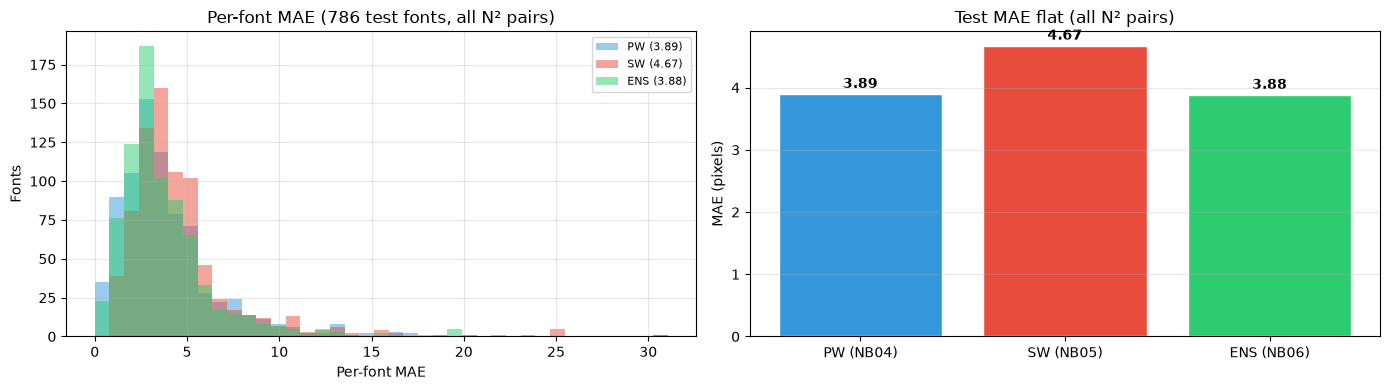

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mx = font_mae[["mae_pw", "mae_sw", "mae_ens"]].max().max()
b = np.linspace(0, mx, 40)
axes[0].hist(font_mae["mae_pw"], bins=b, alpha=0.5, color="#3498db", label=f"PW ({font_mae['mae_pw'].mean():.2f})")
axes[0].hist(font_mae["mae_sw"], bins=b, alpha=0.5, color="#e74c3c", label=f"SW ({font_mae['mae_sw'].mean():.2f})")
axes[0].hist(font_mae["mae_ens"], bins=b, alpha=0.5, color="#2ecc71", label=f"ENS ({font_mae['mae_ens'].mean():.2f})")
axes[0].set_title(f"Per-font MAE ({len(font_mae)} test fonts, all N² pairs)")
axes[0].set_xlabel("Per-font MAE"); axes[0].set_ylabel("Fonts")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

models = ["PW (NB04)", "SW (NB05)", "ENS (NB06)"]
vals = [pw_mae, sw_mae, ens_mae]
colors = ["#3498db", "#e74c3c", "#2ecc71"]
bars = axes[1].bar(models, vals, color=colors, edgecolor="white")
for b, v in zip(bars, vals):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.1, f"{v:.2f}", ha="center", fontweight="bold")
axes[1].set_title("Test MAE flat (all N² pairs)")
axes[1].set_ylabel("MAE (pixels)"); axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

